# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [9]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [10]:
df=pd.read_csv('cleaned_aviation_data.csv')
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Occupants,fatality_rate,serious_injury_rate,severe_injury_rate,is_destroyed
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,UNKNOWN,CRUISE,Probable Cause,NaN,2.0,1.000000,0.000000,1.0,1
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,UNKNOWN,UNKNOWN,Probable Cause,19-09-1996,4.0,1.000000,0.000000,1.0,1
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,0.0,IMC,CRUISE,Probable Cause,26-02-2007,3.0,1.000000,0.000000,1.0,1
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,IMC,CRUISE,Probable Cause,12-09-2000,2.0,1.000000,0.000000,1.0,1
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,0.0,VMC,APPROACH,Probable Cause,16-04-1980,3.0,0.333333,0.666667,1.0,1


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [11]:
# Clasify either aircraft large or small based on criteria
df['aircraft_size'] = df['Total.Occupants'].apply(
    lambda x: 'Large' if x > 20 else 'Small'
)
#Split Data set 
df_small = df[df['aircraft_size'] == 'Small'].copy()
df_large = df[df['aircraft_size'] == 'Large'].copy()

In [14]:
#aircraft type was dropped -Recreate it again
#start by creating it
df['Make'] = df['Make'].astype(str).str.strip().str.upper()
df['Model'] = df['Model'].astype(str).str.strip().str.upper()
#create aircraft_type column
df['aircraft_type'] = df['Make'] + " " + df['Model']
#confirm/valaidate
print(df.columns)
#recreate samll an large
df_small = df[df['aircraft_size'] == 'Small'].copy()
df_large = df[df['aircraft_size'] == 'Large'].copy()

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'Total.Occupants', 'fatality_rate', 'serious_injury_rate',
       'severe_injury_rate', 'is_destroyed', 'aircraft_size', 'aircraft_type'],
      dtype='object')


In [15]:
#Aggregate Safety metrics by Aircraft Type
#Assumption Low severe injury rate
#Low destruction rate
#Sufficient sample size (≥30 accidents)
#Small aircraft analysis
small_summary = df_small.groupby('aircraft_type').agg(
    accidents=('aircraft_type', 'count'),
    avg_fatality_rate=('fatality_rate', 'mean'),
    avg_severe_injury_rate=('severe_injury_rate', 'mean'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
# Keep statistically robust results
small_summary = small_summary[small_summary['accidents'] >= 30]
small_summary.sort_values('avg_severe_injury_rate').head(10)
#Large aircraft Analysis
large_summary = df_large.groupby('aircraft_type').agg(
    accidents=('aircraft_type', 'count'),
    avg_fatality_rate=('fatality_rate', 'mean'),
    avg_severe_injury_rate=('severe_injury_rate', 'mean'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
large_summary = large_summary[large_summary['accidents'] >= 30]
large_summary.sort_values('avg_severe_injury_rate').head(10)

,aircraft_type,accidents,avg_fatality_rate,avg_severe_injury_rate,destruction_rate
724,MCDONNELL DOUGLAS DC-10-10,32,0.011719,0.019845,0.031250
399,BOEING 777,38,0.000000,0.026029,0.026316
161,BOEING 727-200,38,0.026316,0.030493,0.026316
743,MCDONNELL DOUGLAS DC-9-82,31,0.031518,0.034083,0.032258
340,BOEING 757,30,0.033333,0.034752,0.066667
363,BOEING 767,36,0.019841,0.040867,0.027778
249,BOEING 737-300,42,0.056031,0.066490,0.095238
202,BOEING 737,204,0.052792,0.066865,0.053922
224,BOEING 737-200,42,0.215795,0.237611,0.285714


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [16]:
#Creating Severe Injury Rate
df['severe_injury_rate'] = (
    df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']
) / df['Total.Occupants']
#Aggregate Small Aircraft (Small Vs Large)
# First Small Aircraft 
small_make_summary = df_small.groupby('Make').agg(
    accidents=('Make', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean')
).reset_index()
# Ensure statistical robustness
small_make_summary = small_make_summary[small_make_summary['accidents'] >= 30]
# Get safest 15
small_top15 = small_make_summary.nsmallest(15, 'mean_severe_rate')
#Second Large Aircraft
large_make_summary = df_large.groupby('Make').agg(
    accidents=('Make', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean')
).reset_index()
large_make_summary = large_make_summary[large_make_summary['accidents'] >= 30]
large_top15 = large_make_summary.nsmallest(15, 'mean_severe_rate')

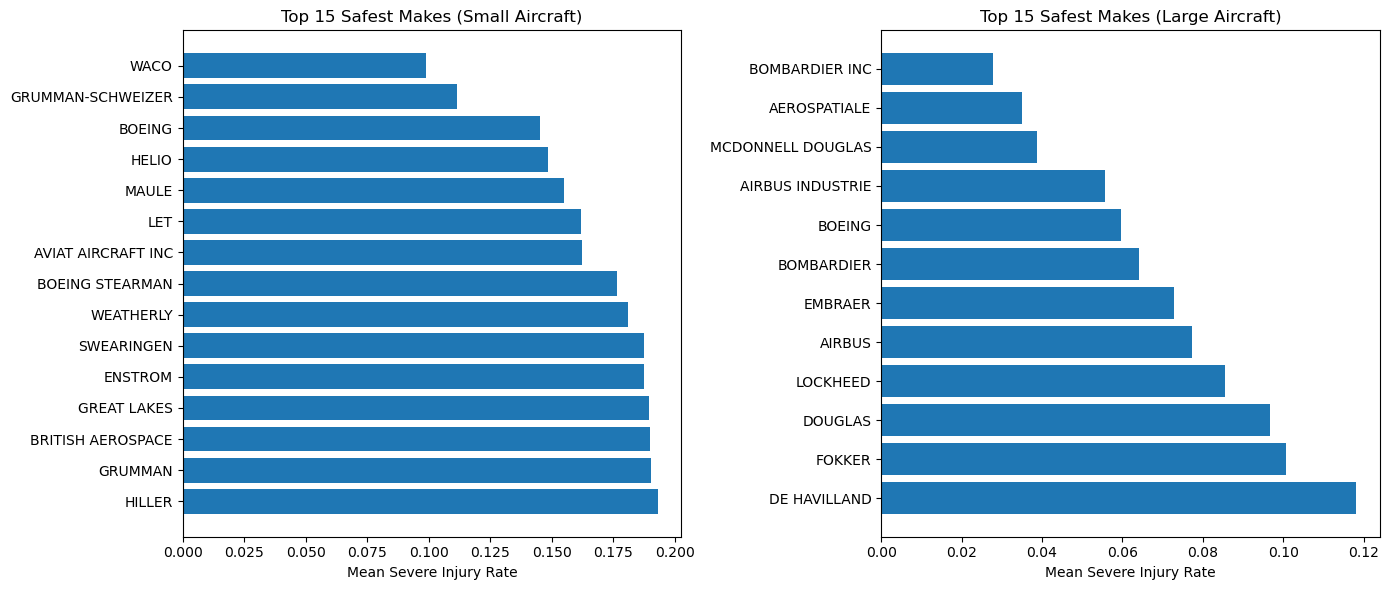

In [17]:
#Plot side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Small aircraft plot
axes[0].barh(small_top15['Make'], small_top15['mean_severe_rate'])
axes[0].set_title('Top 15 Safest Makes (Small Aircraft)')
axes[0].set_xlabel('Mean Severe Injury Rate')
axes[0].invert_yaxis()
# Large aircraft plot
axes[1].barh(large_top15['Make'], large_top15['mean_severe_rate'])
axes[1].set_title('Top 15 Safest Makes (Large Aircraft)')
axes[1].set_xlabel('Mean Severe Injury Rate')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [18]:
#Top 10 Safest Small Makes (by mean rate)
small_make_summary = df_small.groupby('Make').agg(
    accidents=('Make', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean')
).reset_index()
# Keep robust makes
small_make_summary = small_make_summary[small_make_summary['accidents'] >= 30]
# Top 10 safest
top10_small_makes = small_make_summary.nsmallest(10, 'mean_severe_rate')['Make']
#Filftering data for those Makes only
df_small_top10 = df_small[df_small['Make'].isin(top10_small_makes)].copy()

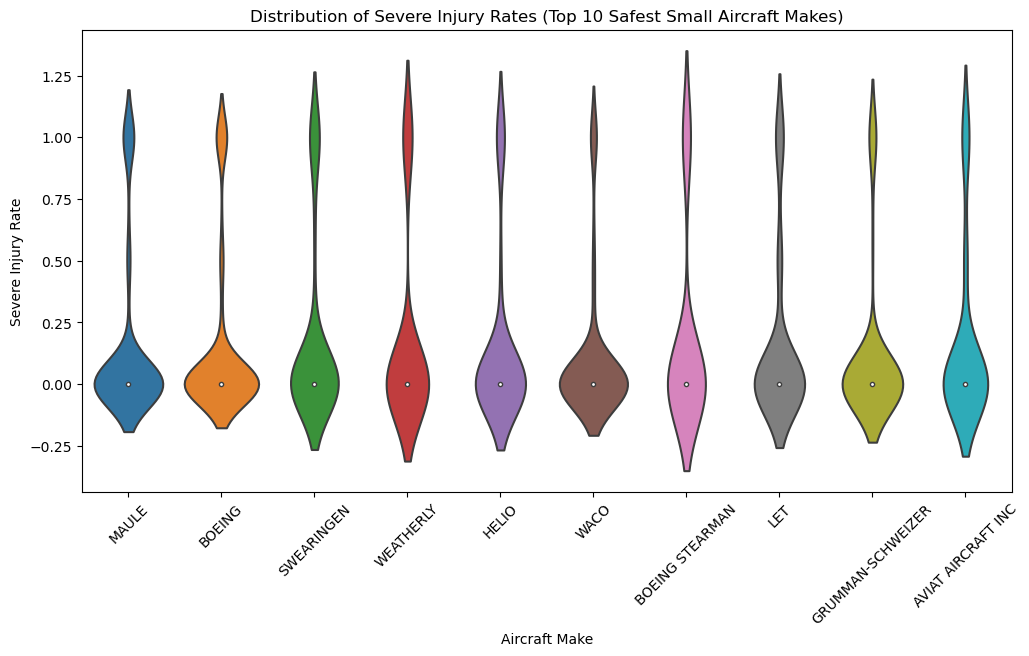

In [19]:
#Ploting violin Plot
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_small_top10,
    x='Make',
    y='severe_injury_rate'
)
plt.title('Distribution of Severe Injury Rates (Top 10 Safest Small Aircraft Makes)')
plt.xlabel('Aircraft Make')
plt.ylabel('Severe Injury Rate')
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

c:\Users\fkamau\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\fkamau\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


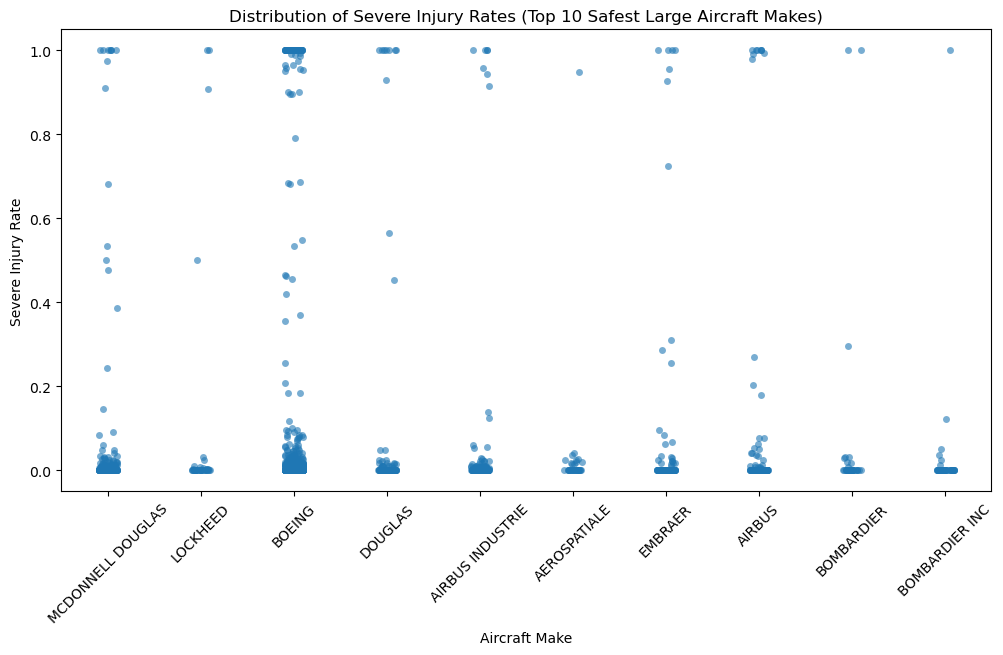

In [21]:
#Top 10 Largest Makes 
large_make_summary = df_large.groupby('Make').agg(
    accidents=('Make', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean')
).reset_index()
# Ensure robustness
large_make_summary = large_make_summary[large_make_summary['accidents'] >= 30]
# Top 10 safest
top10_large_makes = large_make_summary.nsmallest(10, 'mean_severe_rate')['Make']
#Filter data for those Makes
df_large_top10 = df_large[df_large['Make'].isin(top10_large_makes)].copy()
#Replace Avoid dividing by 0
df_large_top10['severe_injury_rate'] = df_large_top10['severe_injury_rate'].replace([np.inf, -np.inf], np.nan)
#drop for proper ploting 
df_large_top10 = df_large_top10.dropna(subset=['severe_injury_rate'])
#Plot strip plot
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_large_top10,
    x='Make',
    y='severe_injury_rate',
    jitter=True,
    alpha=0.6
)
plt.title('Distribution of Severe Injury Rates (Top 10 Safest Large Aircraft Makes)')
plt.xlabel('Aircraft Make')
plt.ylabel('Severe Injury Rate')
plt.xticks(rotation=45)

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [22]:
#Ensures destrcution varibles exist
df['is_destroyed'] = (df['Aircraft.damage'] == 'Destroyed').astype(int)
#Small Aircraft -Destrcuition Rate by Make
small_destruction = df_small.groupby('Make').agg(
    accidents=('Make', 'count'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
# Keep statistically robust makes
small_destruction = small_destruction[small_destruction['accidents'] >= 30]
# Lowest 15 (safest)
small_destruction_top15 = small_destruction.nsmallest(15, 'destruction_rate')
small_destruction_top15

,Make,accidents,destruction_rate
48,GRUMMAN ACFT ENG COR-SCHWEIZER,58,0.017241
10,AMERICAN CHAMPION AIRCRAFT,54,0.037037
12,AVIAT AIRCRAFT INC,77,0.038961
33,DEHAVILLAND,100,0.040000
34,DIAMOND AIRCRAFT IND INC,74,0.054054
42,FLIGHT DESIGN GMBH,50,0.060000
78,ROBINSON HELICOPTER,229,0.061135
14,BALLOON WORKS,147,0.061224
60,LET,136,0.080882
75,RAVEN,86,0.081395


In [23]:
#Large Aircraft -Destrcuition Rate by Make
large_destruction = df_large.groupby('Make').agg(
    accidents=('Make', 'count'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
large_destruction = large_destruction[large_destruction['accidents'] >= 30]
large_destruction_top15 = large_destruction.nsmallest(15, 'destruction_rate')
large_destruction_top15

,Make,accidents,destruction_rate
8,BOMBARDIER INC,45,0.022222
1,AEROSPATIALE,34,0.029412
7,BOMBARDIER,38,0.052632
6,BOEING,1426,0.060309
25,MCDONNELL DOUGLAS,336,0.062500
15,EMBRAER,110,0.063636
3,AIRBUS INDUSTRIE,138,0.065217
2,AIRBUS,132,0.075758
17,FOKKER,48,0.083333
14,DOUGLAS,96,0.114583


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

RECOMMENDATION & COMMENT
The analysis highlights meaningful differences in safety performance across aircraft manufacturers when evaluating both severe injury rates and destruction rates. Among small aircraft, several makes show low average injury and destruction rates, indicating strong safety performance; however, the distribution plots reveal greater variability, meaning some models still experience occasional high-severity outcomes. In contrast, large aircraft manufacturers generally exhibit lower average injury rates and more tightly clustered distributions, suggesting more consistent and predictable safety performance, likely due to stricter design standards and operational controls.

Based on these findings, it is advisable to prioritize manufacturers that combine low average severe injury rates with low destruction rates, especially those with less variability in outcomes. For small aircraft, selecting makes with both low averages and stable distributions is critical to reducing risk. For large aircraft, the focus should be on consistently high-performing manufacturers with minimal variation in safety outcomes. Using both metrics together provides a more comprehensive basis for selecting safer aircraft and supports more informed, risk-aware decision-making.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

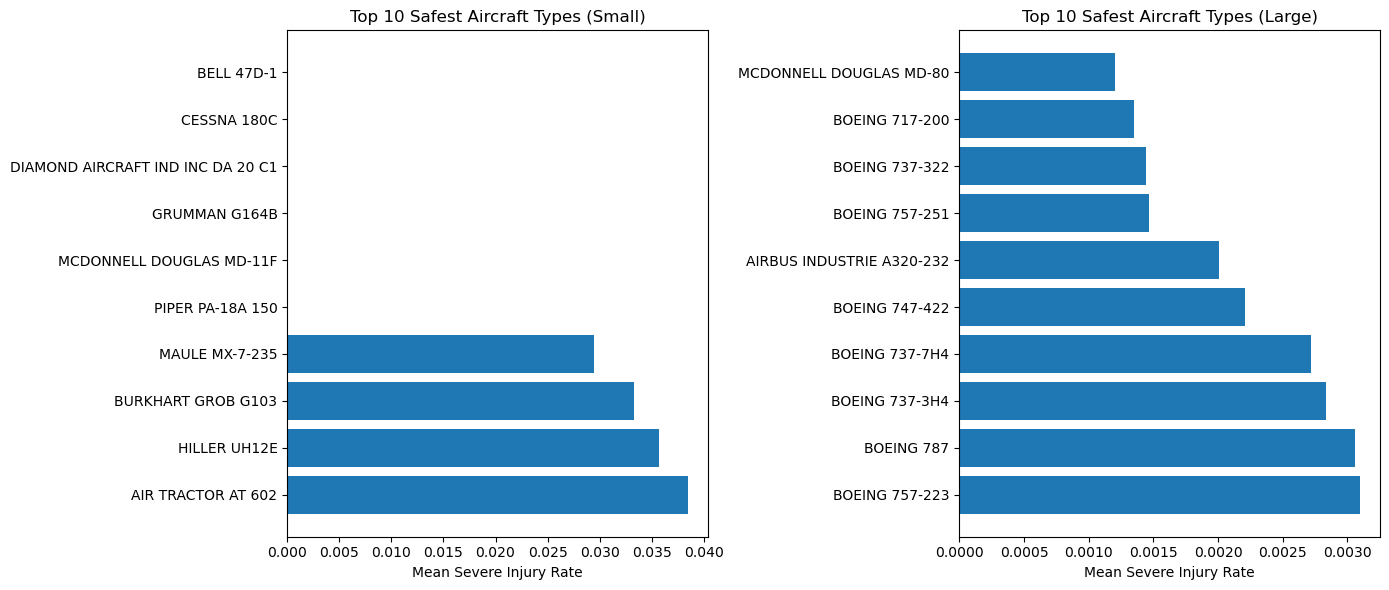

In [27]:
#Check if required column exists
df['aircraft_type'] = df['Make'] + " " + df['Model']
#Filter statistcally for aircraft(>=10 records)
type_counts = df.groupby(['aircraft_size', 'aircraft_type']).size().reset_index(name='count')
valid_types = type_counts[type_counts['count'] >= 10]
df_valid = df.merge(valid_types[['aircraft_size', 'aircraft_type']], 
                    on=['aircraft_size', 'aircraft_type'], 
                    how='inner')
##Compute mean severe injury rate per aircraft type
type_summary = df_valid.groupby(['aircraft_size', 'aircraft_type']).agg(
    mean_severe_rate=('severe_injury_rate', 'mean'),
    accidents=('aircraft_type', 'count')
).reset_index()
#Large 
# Split
small_types = type_summary[type_summary['aircraft_size'] == 'Small']
large_types = type_summary[type_summary['aircraft_size'] == 'Large']
# Sort and take top safest (optional for readability)
small_top = small_types.nsmallest(10, 'mean_severe_rate')
large_top = large_types.nsmallest(10, 'mean_severe_rate')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Small
axes[0].barh(small_top['aircraft_type'], small_top['mean_severe_rate'])
axes[0].set_title('Top 10 Safest Aircraft Types (Small)')
axes[0].set_xlabel('Mean Severe Injury Rate')
axes[0].invert_yaxis()
# Large
axes[1].barh(large_top['aircraft_type'], large_top['mean_severe_rate'])
axes[1].set_title('Top 10 Safest Aircraft Types (Large)')
axes[1].set_xlabel('Mean Severe Injury Rate')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()



**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

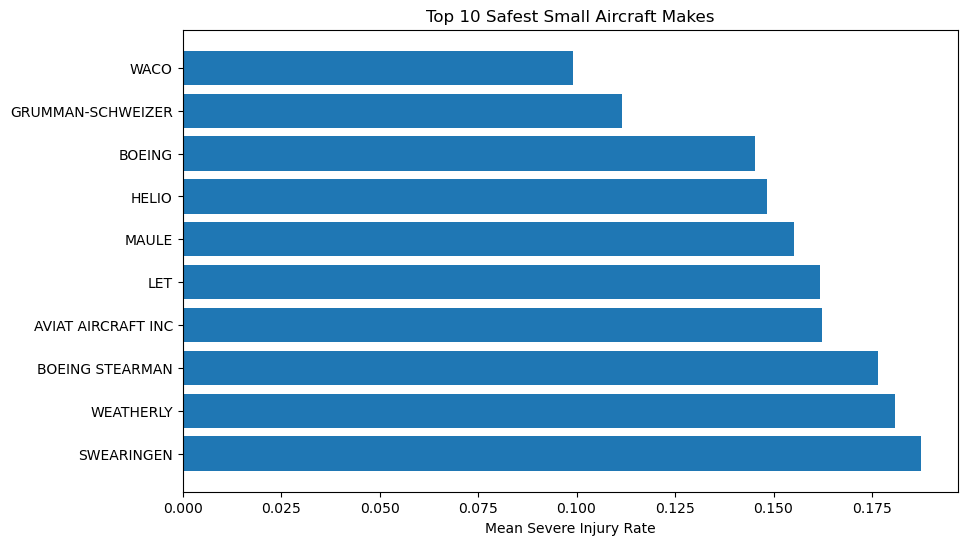

In [28]:
#Identify 10 safest  small Makes
small_make_summary = df_small.groupby('Make').agg(
    accidents=('Make', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean')
).reset_index()
# Ensure statistical reliability
small_make_summary = small_make_summary[small_make_summary['accidents'] >= 30]
# Get 10 lowest (safest)
top10_small_makes = small_make_summary.nsmallest(10, 'mean_severe_rate')
#Plot mean sever mean injuries 
plt.figure(figsize=(10, 6))
plt.barh(top10_small_makes['Make'], top10_small_makes['mean_severe_rate'])
plt.xlabel('Mean Severe Injury Rate')
plt.title('Top 10 Safest Small Aircraft Makes')
plt.gca().invert_yaxis()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#DISCUSSION REGARDING PASSENGER FRACTION SECRIOUSLY/BOTH SMALL AND LARGE AIRPLANE MODELS:

The analysis shows that safety varies significantly at the aircraft model (Make + Model) level, especially for small planes. Among small aircraft, even the safest models (with low average serious/fatal injury rates) tend to have greater variability, meaning some accidents still result in high passenger harm. This suggests that safety outcomes in small aircraft are less consistent and more influenced by external factors like pilot behavior and operating conditions.

In contrast, large aircraft models demonstrate more consistent and lower injury rates, with tighter distributions and fewer extreme outcomes. This reflects stronger engineering standards and more controlled operating environments. Overall, the client should prioritize aircraft types that combine low average injury rates with low variability, with extra caution when selecting small aircraft where differences between models are more pronounced.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

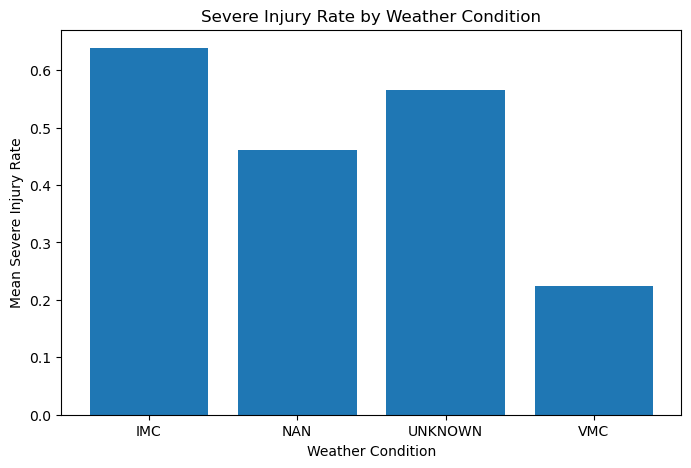

In [29]:
#FACTOR 1 WEATHER CONDITION 
weather_summary = df.groupby('Weather.Condition').agg(
    accidents=('Weather.Condition', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
weather_summary
#VISUALIZATION
plt.figure(figsize=(8,5))
plt.bar(weather_summary['Weather.Condition'], weather_summary['mean_severe_rate'])
plt.title('Severe Injury Rate by Weather Condition')
plt.ylabel('Mean Severe Injury Rate')
plt.xlabel('Weather Condition')
plt.show()

DISCUSSION

Weather conditions have a clear impact on both injury severity and aircraft destruction. Flights operating under IMC (Instrument Meteorological Conditions)—such as poor visibility or bad weather—tend to show higher severe injury and destruction rates compared to VMC (Visual conditions). This suggests that adverse weather significantly increases operational risk, likely due to reduced pilot visibility and more complex navigation requirements.

In contrast, VMC conditions generally show lower and more stable injury rates, indicating safer operating environments. This highlights weather as a key external risk factor, reinforcing the importance of advanced navigation systems and pilot training in poor conditions.

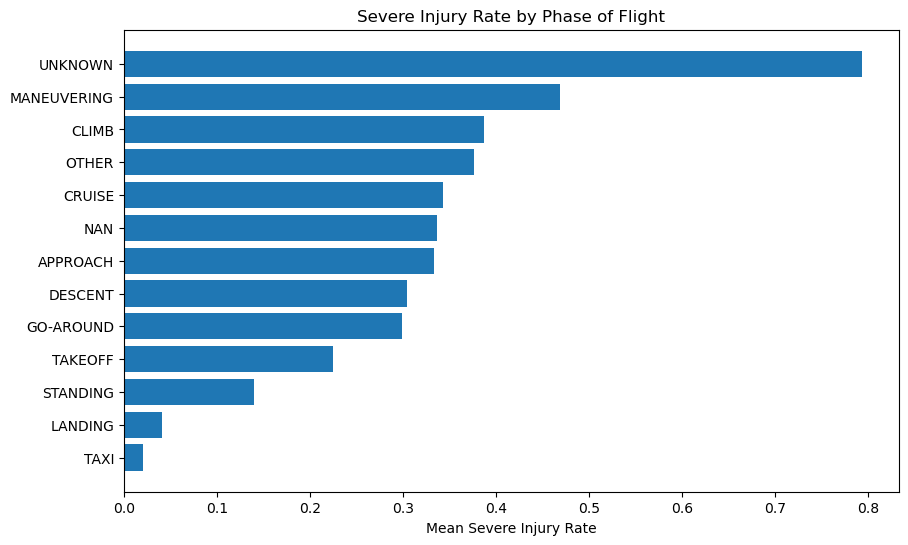

In [30]:
#FACTOR 2 PHASE OF FLIGHT
#ANALYSIS
phase_summary = df.groupby('Broad.phase.of.flight').agg(
    accidents=('Broad.phase.of.flight', 'count'),
    mean_severe_rate=('severe_injury_rate', 'mean'),
    destruction_rate=('is_destroyed', 'mean')
).reset_index()
phase_summary = phase_summary.sort_values('mean_severe_rate', ascending=False)
phase_summary
#VISUALIZATION
plt.figure(figsize=(10,6))
plt.barh(
    phase_summary['Broad.phase.of.flight'],
    phase_summary['mean_severe_rate']
)
plt.title('Severe Injury Rate by Phase of Flight')
plt.xlabel('Mean Severe Injury Rate')
plt.gca().invert_yaxis()
plt.show()

DISCUSSION:

The phase of flight is one of the strongest determinants of accident severity. Phases such as takeoff, climb, and landing/approach tend to exhibit higher severe injury and destruction rates, as these are the most operationally demanding stages of flight with limited recovery time in case of failure.

In contrast, the cruise phase generally shows lower injury severity, reflecting more stable flight conditions and greater opportunity for corrective action. This pattern highlights that safety risks are not evenly distributed across flight operations—critical transition phases carry disproportionately higher risk.